In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, export_text


In [2]:
!pip install -q kaggle
!kaggle datasets download -d amitanshjoshi/spotify-1million-tracks --unzip

Dataset URL: https://www.kaggle.com/datasets/amitanshjoshi/spotify-1million-tracks
License(s): ODbL-1.0
100% 77.1M/77.1M [00:00<00:00, 130MB/s]



In [3]:
df = pd.read_csv('/content/spotify_data.csv')
df.head()

,Unnamed: 0,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0,Jason Mraz,I Won't Give Up,53QF56cjZA9RTuuMZDrSA6,68,2012,acoustic,0.483,0.303,4,-10.058,1,0.0429,0.6940,0.000000,0.1150,0.139,133.406,240166,3
1,1,Jason Mraz,93 Million Miles,1s8tP3jP4GZcyHDsjvw218,50,2012,acoustic,0.572,0.454,3,-10.286,1,0.0258,0.4770,0.000014,0.0974,0.515,140.182,216387,4
2,2,Joshua Hyslop,Do Not Let Me Go,7BRCa8MPiyuvr2VU3O9W0F,57,2012,acoustic,0.409,0.234,3,-13.711,1,0.0323,0.3380,0.000050,0.0895,0.145,139.832,158960,4
3,3,Boyce Avenue,Fast Car,63wsZUhUZLlh1OsyrZq7sz,58,2012,acoustic,0.392,0.251,10,-9.845,1,0.0363,0.8070,0.000000,0.0797,0.508,204.961,304293,4
4,4,Andrew Belle,Sky's Still Blue,6nXIYClvJAfi6ujLiKqEq8,54,2012,acoustic,0.430,0.791,6,-5.419,0,0.0302,0.0726,0.019300,0.1100,0.217,171.864,244320,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1159764 entries, 0 to 1159763
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Unnamed: 0        1159764 non-null  int64  
 1   artist_name       1159749 non-null  object 
 2   track_name        1159763 non-null  object 
 3   track_id          1159764 non-null  object 
 4   popularity        1159764 non-null  int64  
 5   year              1159764 non-null  int64  
 6   genre             1159764 non-null  object 
 7   danceability      1159764 non-null  float64
 8   energy            1159764 non-null  float64
 9   key               1159764 non-null  int64  
 10  loudness          1159764 non-null  float64
 11  mode              1159764 non-null  int64  
 12  speechiness       1159764 non-null  float64
 13  acousticness      1159764 non-null  float64
 14  instrumentalness  1159764 non-null  float64
 15  liveness          1159764 non-null  float64
 16  

In [5]:
df.shape

(1159764, 20)

#EDA

array([[<Axes: title={'center': 'Unnamed: 0'}>,
        <Axes: title={'center': 'popularity'}>,
        <Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'danceability'}>],
       [<Axes: title={'center': 'energy'}>,
        <Axes: title={'center': 'key'}>,
        <Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'mode'}>],
       [<Axes: title={'center': 'speechiness'}>,
        <Axes: title={'center': 'acousticness'}>,
        <Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>],
       [<Axes: title={'center': 'valence'}>,
        <Axes: title={'center': 'tempo'}>,
        <Axes: title={'center': 'duration_ms'}>,
        <Axes: title={'center': 'time_signature'}>],
       [<Axes: title={'center': 'artist_encoded'}>,
        <Axes: title={'center': 'genre_encoded'}>, <Axes: >, <Axes: >]],
      dtype=object)

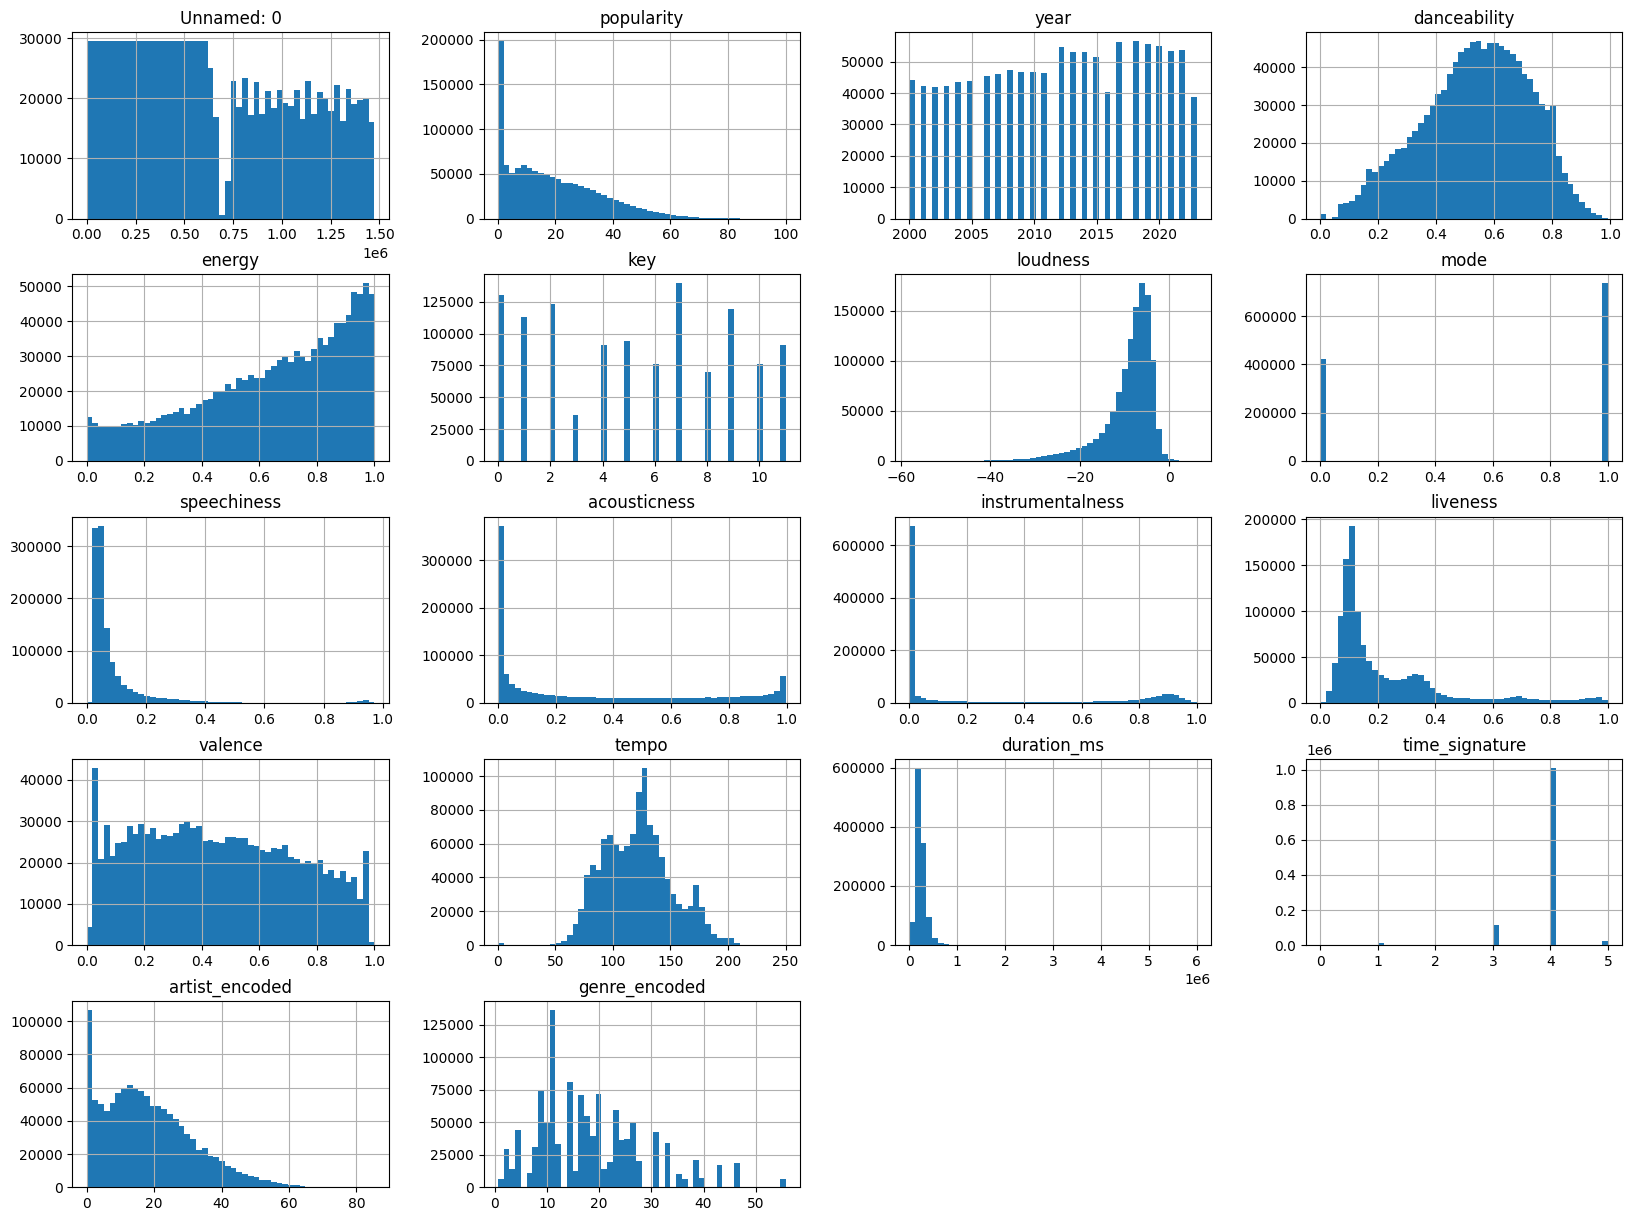

In [13]:
df.hist(bins=50, figsize=(20, 15))

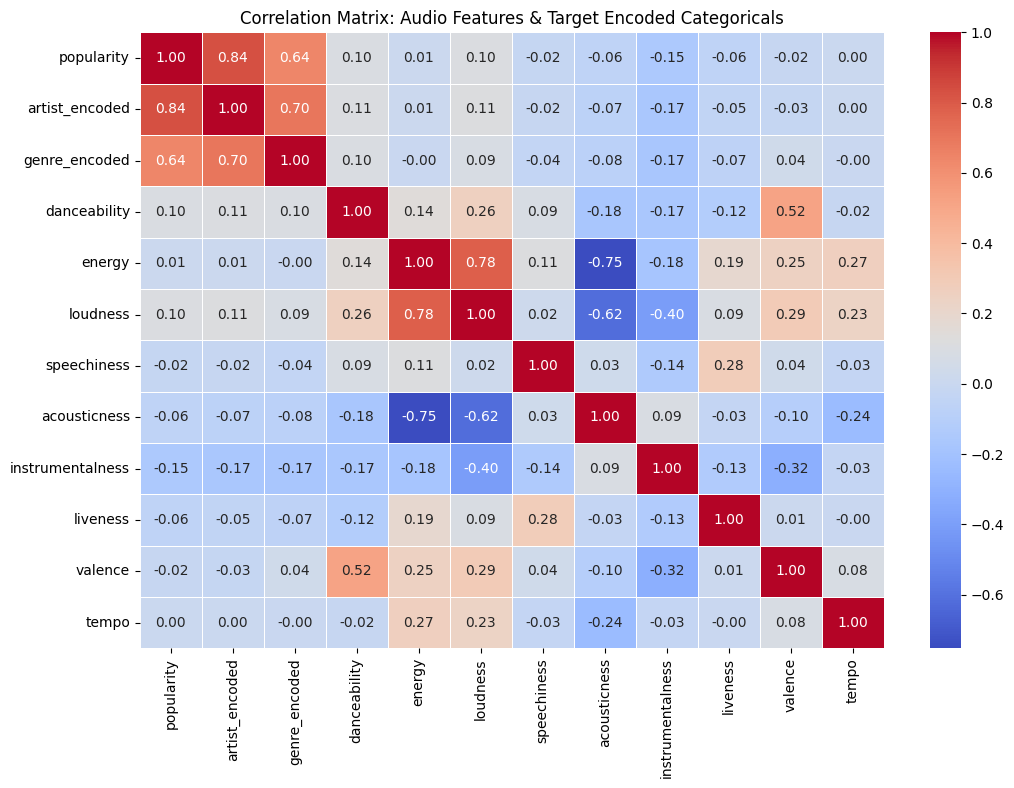


--- Correlation with Popularity ---
popularity          1.000000
artist_encoded      0.835168
genre_encoded       0.642420
loudness            0.104097
danceability        0.098533
energy              0.009401
tempo               0.002566
valence            -0.018070
speechiness        -0.024700
liveness           -0.056968
acousticness       -0.059181
instrumentalness   -0.152893
Name: popularity, dtype: float64


In [10]:
artist_means = df.groupby('artist_name')['popularity'].mean()
genre_means = df.groupby('genre')['popularity'].mean()

# Calculate Target Encoding Safely
artist_means = df.groupby('artist_name')['popularity'].mean()
genre_means = df.groupby('genre')['popularity'].mean()

df['artist_encoded'] = df['artist_name'].map(artist_means)
df['genre_encoded'] = df['genre'].map(genre_means)

eda_cols = [
    'popularity', 'artist_encoded', 'genre_encoded', 'danceability',
    'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo'
]
corr_matrix = df[eda_cols].corr()

# Plot the Correlation Matrix Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Audio Features & Target Encoded Categoricals")
plt.show()

print("\n--- Correlation with Popularity ---")
print(corr_matrix['popularity'].sort_values(ascending=False))

#Baseline Model

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

X = df[eda_cols].drop(columns=['popularity'])
y = df['popularity']

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeRegressor(max_depth=5, random_state=42)
model.fit(X_tr, y_tr)

print(f"Train R² Score: {model.score(X_tr, y_tr):.4f}")
print(f"Test R² Score: {model.score(X_te, y_te):.4f}")


Train R² Score: 0.7056
Test R² Score: 0.7051


In [19]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from time import time

start = time()

grid = {
    "criterion": ["squared_error", "friedman_mse"],
    "max_depth": [3, 5, 8, 12, None],
    "max_leaf_nodes": [10, 20, 50, 100, None]     # Added controlled node limits
}

rs = RandomizedSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_distributions=grid,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=1
)

print("Starting fast hyperparameter sweep using RandomizedSearchCV...")
rs.fit(X_tr, y_tr)
end = time()

print("\n--- Structural Optimization Results ---")
print(f"Execution Time: {end - start:.2f} seconds")
print(f"Best Parameters Found: {rs.best_params_}")
print(f"Best CV Score (Negative MSE): {rs.best_score_:.4f}")

best_model = rs.best_estimator_
test_r2 = best_model.score(X_te, y_te)
print(f"Test Set R² Accuracy: {test_r2:.4f}")

Starting fast hyperparameter sweep using RandomizedSearchCV...

--- Structural Optimization Results ---
Execution Time: 594.25 seconds
Best Parameters Found: {'max_leaf_nodes': None, 'max_depth': 8, 'criterion': 'friedman_mse'}
Best CV Score (Negative MSE): -72.7059
Test Set R² Accuracy: 0.7116


--- Feature Importances Table ---
         Feature  Importance
  artist_encoded    0.976350
   genre_encoded    0.022147
    acousticness    0.000420
        loudness    0.000292
instrumentalness    0.000246
        liveness    0.000202
    danceability    0.000087
     speechiness    0.000083
         valence    0.000071
           tempo    0.000052
          energy    0.000050


/tmp/ipykernel_6927/382562704.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


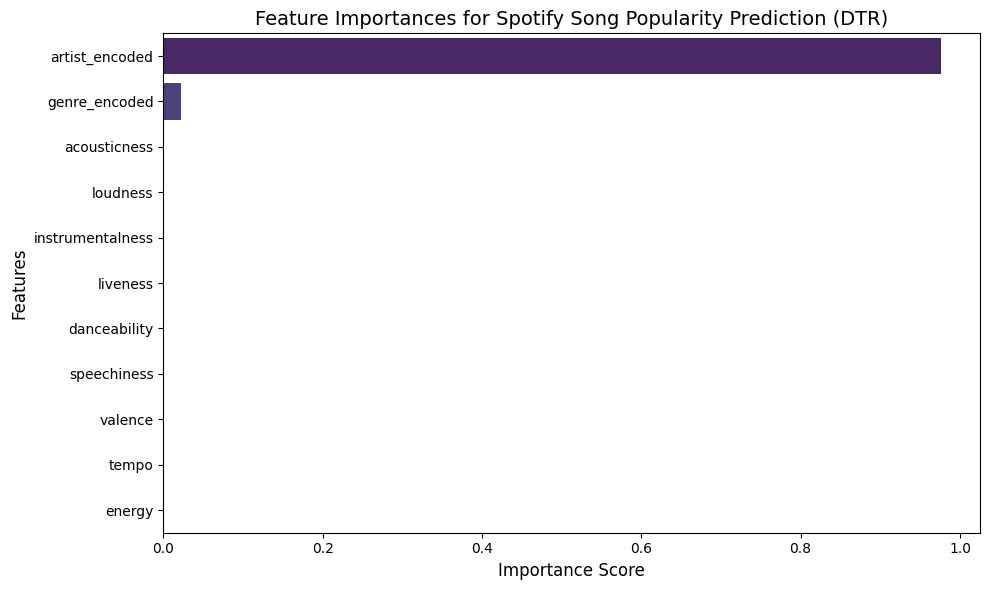

In [21]:
importances = best_model.feature_importances_
feature_names = list(X_tr.columns)

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("--- Feature Importances Table ---")
print(feat_imp_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importances for Spotify Song Popularity Prediction (DTR)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()

plt.savefig('feature_importance.png', dpi=300)
plt.show()